<a href="https://colab.research.google.com/github/Salina2060/Artificial-Intelligence-and-Machine-Learning/blob/main/Worksheet5_Implementation_of_Convolutional_Neural_Network_using_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Salina Pudasaini**

**University Id: 2407800**

**Artificial Intelligence and Machine Learning. Implementation of Convolutional Neural Network using Keras.**

**Unzipping the file**

In [2]:
zip_path = "/content/drive/MyDrive/AI and MachineLearning/Week5/Copy of FruitinAmazon.zip"

In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and MachineLearning/Week5/Copy of FruitinAmazon.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import os
os.listdir("/content/data")

['FruitinAmazon']

# **Exercise**

**Objective**

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.

** *italicized text*Task 1: Data Understanding and Visualization:**

**1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:**

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

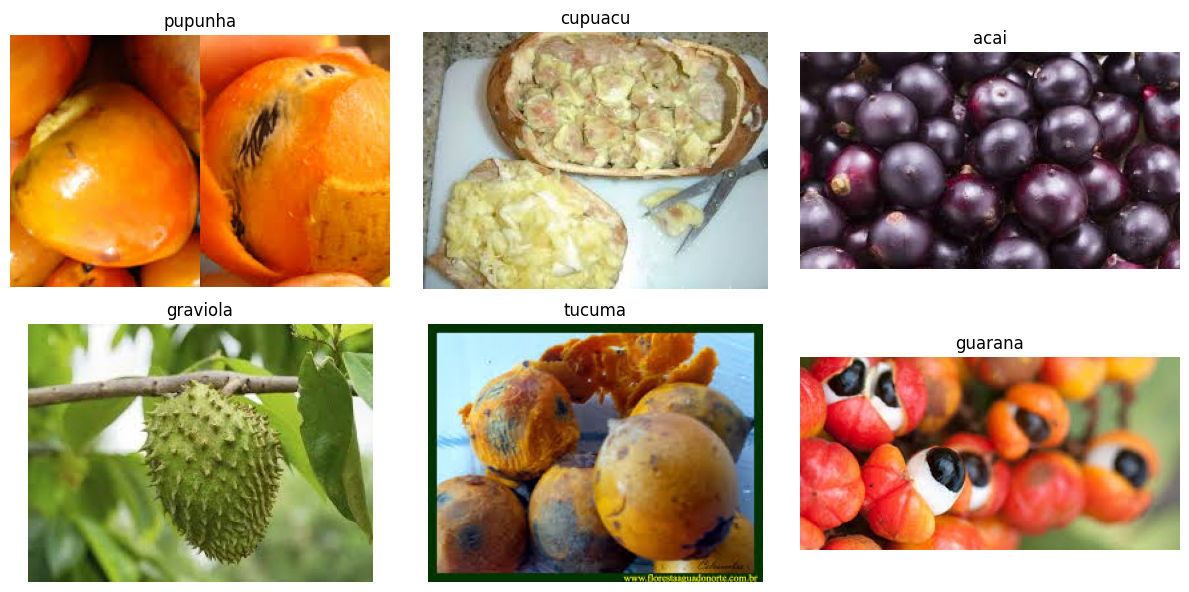

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = '/content/data/FruitinAmazon/train'

classes = []
for folder_name in os.listdir(train_dir):
    if os.path.isdir(os.path.join(train_dir, folder_name)):
        classes.append(folder_name)

num_classes = len(classes)
cols = (num_classes + 1) // 2  # Calculate how many columns we need for 2 rows
fig, axes = plt.subplots(nrows=2, ncols=cols, figsize=(12, 6))

# Flatten the axes array to easily loop through it
axes = axes.flatten()

# 2. Select one image randomly from each class and 3. Display them
for i in range(len(classes)):
    class_name = classes[i]
    class_path = os.path.join(train_dir, class_name)

    # Get a list of all files in this class folder
    all_images = os.listdir(class_path)

    # Make sure the folder is not empty
    if len(all_images) > 0:
        # Select one random image
        random_image_name = random.choice(all_images)
        image_path = os.path.join(class_path, random_image_name)

        # Load and display the image
        img = mpimg.imread(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off') # Hide the axis ticks

# Hide any extra empty plots if you have an odd number of classes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Check for Corrupted Image:** Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

**• Hint:**
– Iterate through each class subdirectory and check if each image is valid.
– Use the Image.open() function to attempt to load each image.
– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".
– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.

In [6]:
import os
from PIL import Image

# Define the path to your training folder
train_dir = '/content/data/FruitinAmazon/train'

# Maintain a list of all corrupted image paths for reporting
corrupted_images = []

# Iterate through each class subdirectory
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)

    # Make sure we are only looking inside directories
    if os.path.isdir(class_path):

        # Check each image inside this class folder
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Use Image.open() to attempt to load each image
                img = Image.open(image_path)
                img.verify() # This specifically verifies if the image is valid
            except (IOError, SyntaxError):
                # If the image is corrupted, remove it
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")
# Reporting the final outcome
if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [7]:
import tensorflow as tf

# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Apply the normalization (Rescaling) to the datasetand validation dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


**Task 3 - Implement a CNN with**

**Convolutional Architecture:**

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu', input_shape=(128, 128, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),


    # Flatten Layer
    layers.Flatten(),

    # Hidden Layer 1
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Compile the Model**

**• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).**

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


**Task 4: Train the Model**

**Model Training**

**• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs to 250.**

**• Use val ds for validation.**

**• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid- ing overfitting.**

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1591 - loss: 1.9323
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 593ms/step - accuracy: 0.1806 - loss: 1.9931 - val_accuracy: 0.8333 - val_loss: 1.2079
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.2269 - loss: 1.6937
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.3056 - loss: 1.6553 - val_accuracy: 0.2778 - val_loss: 1.7238
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2824 - loss: 1.5444
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - accuracy: 0.3472 - loss: 1.5030 - val_accuracy: 0.6667 - val_loss: 1.4451
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.6887 - loss: 1.2438
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 894ms/step - accuracy: 0.7222 - loss: 1.2066 - val_accuracy: 0.7222 - val_loss: 1.1663
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7361 - loss:


Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 584ms/step - accuracy: 0.8750 - loss: 0.3996 - val_accuracy: 0.8889 - val_loss: 0.4098
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9797 - loss: 0.2060
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.9861 - loss: 0.1931 - val_accuracy: 0.6667 - val_loss: 0.5316
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9653 - loss: 0.1871
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 821ms/step - accuracy: 0.9583 - loss: 0.1996 - val_accuracy: 0.8333 - val_loss: 0.4549
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9902 - loss: 0.1132
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 497ms/step - accuracy: 0.9861 - loss: 0.1054 - val_accuracy: 0.8333 - val_loss: 0.4310
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9803 

**Task 5: Evaluate the Model**

**Model Evaluation**

**• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.**

In [12]:
#Evaluate the model on the validation/test set
test_loss, test_accuracy = model.evaluate(val_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8889 - loss: 0.1744
Test Loss: 0.1744
Test Accuracy: 0.8889


**Task 6: Save and Load the Model**

**Model Saving and Loading**

**• Save the trained model to an .h5 file using model.save().**

**• Load the saved model and re-evaluate its performance on the test set.**

In [13]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model.save('fruit_classifier_final.h5')
print("Model saved as fruit_classifier_final.h5")

# Load the saved model
loaded_model = load_model('fruit_classifier_final.h5')
print("Model loaded successfully.")

#Re-evaluate the loaded model on val_ds to confirm performance
print("Re-evaluating loaded model...")
loaded_model.evaluate(val_ds)

Model saved as fruit_classifier_final.h5
Model loaded successfully.
Re-evaluating loaded model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step - accuracy: 0.8889 - loss: 0.1744


[0.17437487840652466, 0.8888888955116272]

**Task 7: Predictions and Classification Report**

**Making Predictions**

**• Use model.predict() to make predictions on test images.**

**• Convert the model’s predicted probabilities to digit labels using np.argmax().**

**• Also use from sklearn.metrics import classification report to report the Classification Report of your Model Performance.**

In [14]:
import numpy as np
from sklearn.metrics import classification_report

#Use model.predict() to make predictions on test images
predictions = loaded_model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)


unique_labels = np.unique(y_true)
target_names = [class_names[i] for i in unique_labels]

print("\n Final Classification Report")
print(classification_report(y_true, predicted_labels, labels=unique_labels, target_names=target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step

 Final Classification Report
              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       1.00      0.93      0.97        15

   micro avg       1.00      0.89      0.94        18
   macro avg       1.00      0.80      0.88        18
weighted avg       1.00      0.89      0.94        18



**Accuracy and Loss Graphs**

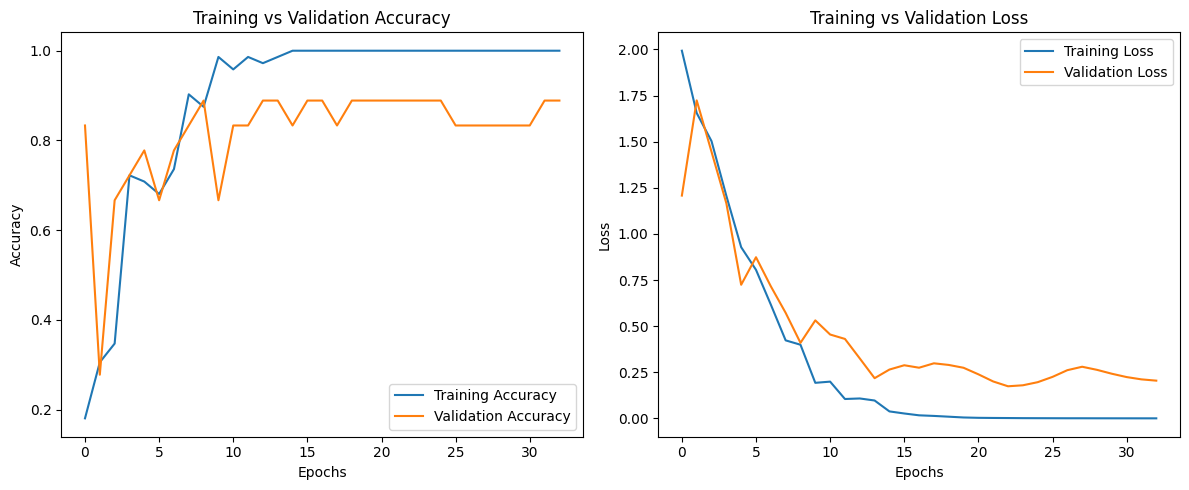

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()